<a href="https://colab.research.google.com/github/kimshy22/SOH_NASA/blob/main/B0007_new_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = "/content/drive/MyDrive/NASA_DATA_SCRIPTS/B007_data/B0007_cycle_level.csv"

df = pd.read_csv(file_path)

df.head()

,battery_id,cycle_id,config_name,event_id,event_type,valid_for_direct_soh,row_mode,measured_capacity_ah,corrected_capacity_ah,estimated_full_capacity_ah,...,max_voltage_v,voltage_drop_v,avg_discharge_current_a,avg_charge_current_a,avg_temperature_c,soc_start,soc_end,soc_window,needs_soc_window_correction,notes
0,B0007,2,nasa_b0007,2,full_discharge,True,discharge,1.918465,1.918465,1.918465,...,3.985606,1.839631,1.990169,0.0,32.375164,NaN,NaN,NaN,False,Looks like a full discharge event.
1,B0007,4,nasa_b0007,5,full_discharge,True,discharge,1.908111,1.908111,1.908111,...,3.990235,1.879219,1.989754,0.0,32.505157,NaN,NaN,NaN,False,Looks like a full discharge event.
2,B0007,6,nasa_b0007,8,full_discharge,True,discharge,1.908103,1.908103,1.908103,...,3.992171,1.967062,1.989869,0.0,32.471508,NaN,NaN,NaN,False,Looks like a full discharge event.
3,B0007,8,nasa_b0007,11,full_discharge,True,discharge,1.908258,1.908258,1.908258,...,3.993218,2.070676,1.989920,0.0,32.360627,NaN,NaN,NaN,False,Looks like a full discharge event.
4,B0007,10,nasa_b0007,14,full_discharge,True,discharge,1.906847,1.906847,1.906847,...,3.993959,2.122800,1.989604,0.0,32.270931,NaN,NaN,NaN,False,Looks like a full discharge event.


In [7]:
df = df.sort_values("cycle_id").reset_index(drop=True)

important_cols = [
    "cycle_id",
    "corrected_capacity_ah",
    "soh_percent_smoothed",
    "duration_s",
    "avg_discharge_current_a",
    "avg_temperature_c",
    "start_voltage_v",
    "end_voltage_v"
]

df = df[important_cols].copy()

df = df.dropna().reset_index(drop=True)

df.head()

,cycle_id,corrected_capacity_ah,soh_percent_smoothed,duration_s,avg_discharge_current_a,avg_temperature_c,start_voltage_v,end_voltage_v
0,2,1.918465,95.923264,3451.375,1.990169,32.375164,3.985606,2.145976
1,4,1.908111,95.483190,3433.250,1.989754,32.505157,3.990235,2.111017
2,6,1.908103,95.416877,3433.093,1.989869,32.471508,3.992171,2.025109
3,8,1.908258,95.413493,3433.282,1.989920,32.360627,3.993218,1.922542
4,10,1.906847,95.353002,3431.328,1.989604,32.270931,3.993959,1.871159


In [8]:
df["soh_current"] = df["soh_percent_smoothed"]

df["capacity_ratio"] = (
    df["corrected_capacity_ah"] / df["corrected_capacity_ah"].iloc[0]
)

df["voltage_drop_v"] = df["start_voltage_v"] - df["end_voltage_v"]

df["delta_soh"] = df["soh_percent_smoothed"].diff()

df["delta_capacity"] = df["corrected_capacity_ah"].diff()

df["recent_slope_3"] = df["delta_soh"].rolling(window=3).mean()

df.head(10)

,cycle_id,corrected_capacity_ah,soh_percent_smoothed,duration_s,avg_discharge_current_a,avg_temperature_c,start_voltage_v,end_voltage_v,soh_current,capacity_ratio,voltage_drop_v,delta_soh,delta_capacity,recent_slope_3
0,2,1.918465,95.923264,3451.375,1.990169,32.375164,3.985606,2.145976,95.923264,1.000000,1.839631,NaN,NaN,NaN
1,4,1.908111,95.483190,3433.250,1.989754,32.505157,3.990235,2.111017,95.483190,0.994603,1.879219,-0.440073,-0.010355,NaN
2,6,1.908103,95.416877,3433.093,1.989869,32.471508,3.992171,2.025109,95.416877,0.994599,1.967062,-0.066314,-0.000007,NaN
3,8,1.908258,95.413493,3433.282,1.989920,32.360627,3.993218,1.922542,95.413493,0.994679,2.070676,-0.003383,0.000154,-0.169924
4,10,1.906847,95.353002,3431.328,1.989604,32.270931,3.993959,1.871159,95.353002,0.993944,2.122800,-0.060491,-0.001411,-0.043396
5,12,1.897065,94.928211,3413.250,1.989797,32.265623,3.994485,2.175687,94.928211,0.988845,1.818799,-0.424791,-0.009782,-0.162889
6,14,1.896223,94.828720,3412.204,1.989603,32.332517,3.995565,2.111789,94.828720,0.988406,1.883776,-0.099491,-0.000842,-0.194924
7,16,1.897810,94.881221,3415.234,1.989511,32.324822,3.997744,2.026251,94.881221,0.989233,1.971493,0.052501,0.001586,-0.157260
8,18,1.896967,94.853289,3413.438,1.989658,32.271583,3.997970,1.950589,94.853289,0.988794,2.047380,-0.027932,-0.000843,-0.024974
9,20,1.897486,94.871139,3414.281,1.989688,32.199666,3.997801,1.868825,94.871139,0.989064,2.128976,0.017850,0.000519,0.014140


In [9]:
df["target_soh_1"] = df["soh_percent_smoothed"].shift(-1)
df["target_soh_5"] = df["soh_percent_smoothed"].shift(-5)

df["target_delta_1"] = df["target_soh_1"] - df["soh_current"]
df["target_delta_5"] = df["target_soh_5"] - df["soh_current"]

df_model = df.dropna().reset_index(drop=True)

df_model.head()

,cycle_id,corrected_capacity_ah,soh_percent_smoothed,duration_s,avg_discharge_current_a,avg_temperature_c,start_voltage_v,end_voltage_v,soh_current,capacity_ratio,voltage_drop_v,delta_soh,delta_capacity,recent_slope_3,target_soh_1,target_soh_5,target_delta_1,target_delta_5
0,8,1.908258,95.413493,3433.282,1.989920,32.360627,3.993218,1.922542,95.413493,0.994679,2.070676,-0.003383,0.000154,-0.169924,95.353002,94.853289,-0.060491,-0.560204
1,10,1.906847,95.353002,3431.328,1.989604,32.270931,3.993959,1.871159,95.353002,0.993944,2.122800,-0.060491,-0.001411,-0.043396,94.928211,94.871139,-0.424791,-0.481863
2,12,1.897065,94.928211,3413.250,1.989797,32.265623,3.994485,2.175687,94.928211,0.988845,1.818799,-0.424791,-0.009782,-0.162889,94.828720,94.870455,-0.099491,-0.057756
3,14,1.896223,94.828720,3412.204,1.989603,32.332517,3.995565,2.111789,94.828720,0.988406,1.883776,-0.099491,-0.000842,-0.194924,94.881221,94.429565,0.052501,-0.399155
4,16,1.897810,94.881221,3415.234,1.989511,32.324822,3.997744,2.026251,94.881221,0.989233,1.971493,0.052501,0.001586,-0.157260,94.853289,94.342027,-0.027932,-0.539194


In [10]:
train_ratio = 0.70
val_ratio = 0.15

n = len(df_model)

train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

train_df = df_model.iloc[:train_end].copy()
val_df = df_model.iloc[train_end:val_end].copy()
test_df = df_model.iloc[val_end:].copy()

print(len(train_df), len(val_df), len(test_df))

112 24 24


In [11]:
test_df["pred_persistence_1"] = test_df["soh_current"]
test_df["pred_persistence_5"] = test_df["soh_current"]

In [12]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print()

evaluate(test_df["target_soh_1"], test_df["pred_persistence_1"], "Persistence 1-cycle")
evaluate(test_df["target_soh_5"], test_df["pred_persistence_5"], "Persistence 5-cycle")

Persistence 1-cycle
MAE  = 0.1774
RMSE = 0.2111

Persistence 5-cycle
MAE  = 0.6114
RMSE = 0.6736



In [13]:
test_df["pred_slope_1"] = test_df["soh_current"] + test_df["recent_slope_3"]

test_df["pred_slope_5"] = test_df["soh_current"] + 5 * test_df["recent_slope_3"]

In [14]:
evaluate(test_df["target_soh_1"], test_df["pred_slope_1"], "Recent slope 1-cycle")
evaluate(test_df["target_soh_5"], test_df["pred_slope_5"], "Recent slope 5-cycle")

Recent slope 1-cycle
MAE  = 0.1642
RMSE = 0.2087

Recent slope 5-cycle
MAE  = 0.6265
RMSE = 0.8639



In [15]:
feature_cols = [
    "cycle_id",
    "soh_current",
    "corrected_capacity_ah",
    "capacity_ratio",
    "delta_soh",
    "delta_capacity",
    "recent_slope_3",
    "duration_s",
    "avg_discharge_current_a",
    "avg_temperature_c",
    "start_voltage_v",
    "end_voltage_v",
    "voltage_drop_v"
]

In [16]:
X_train = train_df[feature_cols]
y_train_delta_1 = train_df["target_delta_1"]

X_test = test_df[feature_cols]

linear_delta_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_delta_1.fit(X_train, y_train_delta_1)

test_df["pred_delta_1"] = linear_delta_1.predict(X_test)

test_df["pred_linear_1"] = test_df["soh_current"] + test_df["pred_delta_1"]

evaluate(test_df["target_soh_1"], test_df["pred_linear_1"], "Linear delta model 1-cycle")

Linear delta model 1-cycle
MAE  = 0.2202
RMSE = 0.2425



In [17]:
y_train_delta_5 = train_df["target_delta_5"]

linear_delta_5 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_delta_5.fit(X_train, y_train_delta_5)

test_df["pred_delta_5"] = linear_delta_5.predict(X_test)

test_df["pred_linear_5"] = test_df["soh_current"] + test_df["pred_delta_5"]

evaluate(test_df["target_soh_5"], test_df["pred_linear_5"], "Linear delta model 5-cycle")

Linear delta model 5-cycle
MAE  = 0.4867
RMSE = 0.5263



In [18]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LinearRegression())
])

X_train_cycle = train_df[["cycle_id"]]
y_train_soh = train_df["soh_percent_smoothed"]

poly_model.fit(X_train_cycle, y_train_soh)

test_df["pred_poly_current"] = poly_model.predict(test_df[["cycle_id"]])

test_df["pred_poly_1"] = poly_model.predict(
    pd.DataFrame({"cycle_id": test_df["cycle_id"] + 1})
)

test_df["pred_poly_5"] = poly_model.predict(
    pd.DataFrame({"cycle_id": test_df["cycle_id"] + 5})
)

evaluate(test_df["target_soh_1"], test_df["pred_poly_1"], "Polynomial trend 1-cycle")
evaluate(test_df["target_soh_5"], test_df["pred_poly_5"], "Polynomial trend 5-cycle")

Polynomial trend 1-cycle
MAE  = 4.5225
RMSE = 4.6298

Polynomial trend 5-cycle
MAE  = 4.3833
RMSE = 4.4930



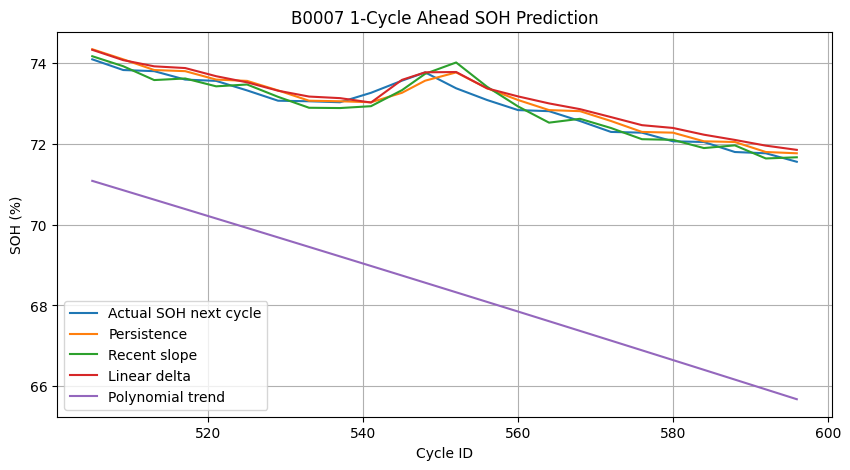

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(test_df["cycle_id"], test_df["target_soh_1"], label="Actual SOH next cycle")
plt.plot(test_df["cycle_id"], test_df["pred_persistence_1"], label="Persistence")
plt.plot(test_df["cycle_id"], test_df["pred_slope_1"], label="Recent slope")
plt.plot(test_df["cycle_id"], test_df["pred_linear_1"], label="Linear delta")
plt.plot(test_df["cycle_id"], test_df["pred_poly_1"], label="Polynomial trend")

plt.xlabel("Cycle ID")
plt.ylabel("SOH (%)")
plt.title("B0007 1-Cycle Ahead SOH Prediction")
plt.legend()
plt.grid(True)
plt.show()

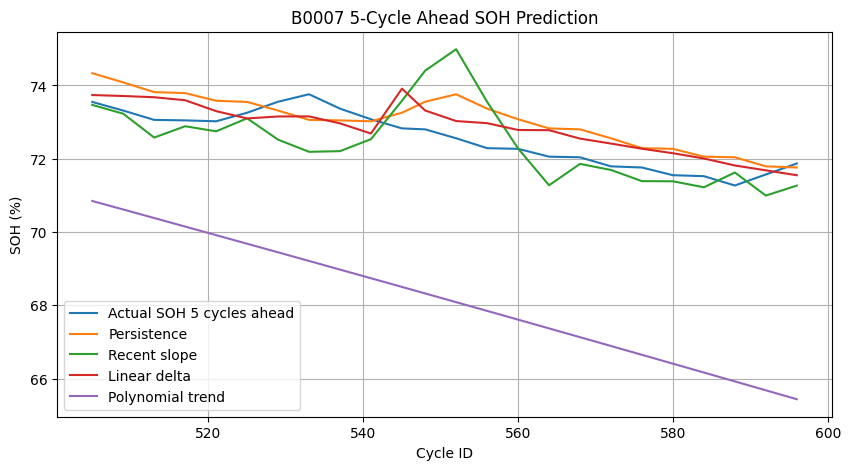

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(test_df["cycle_id"], test_df["target_soh_5"], label="Actual SOH 5 cycles ahead")
plt.plot(test_df["cycle_id"], test_df["pred_persistence_5"], label="Persistence")
plt.plot(test_df["cycle_id"], test_df["pred_slope_5"], label="Recent slope")
plt.plot(test_df["cycle_id"], test_df["pred_linear_5"], label="Linear delta")
plt.plot(test_df["cycle_id"], test_df["pred_poly_5"], label="Polynomial trend")

plt.xlabel("Cycle ID")
plt.ylabel("SOH (%)")
plt.title("B0007 5-Cycle Ahead SOH Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
df_model["soh_percent_smoothed"].min(), df_model["soh_percent_smoothed"].max()

(71.76151895156343, 95.4134930272431)

In [22]:
EOL_THRESHOLD = 70.0

In [23]:
last_cycle = int(df_model["cycle_id"].max())

future_cycles = np.arange(last_cycle, last_cycle + 300)

future_df = pd.DataFrame({"cycle_id": future_cycles})

future_df["predicted_soh"] = poly_model.predict(future_df[["cycle_id"]])

future_df.head()

,cycle_id,predicted_soh
0,596,65.742823
1,597,65.682070
2,598,65.621285
3,599,65.560468
4,600,65.499619


In [24]:
eol_rows = future_df[future_df["predicted_soh"] <= EOL_THRESHOLD]

if len(eol_rows) > 0:
    predicted_eol_cycle = int(eol_rows.iloc[0]["cycle_id"])
    current_cycle = int(df_model["cycle_id"].max())
    rul_cycles = predicted_eol_cycle - current_cycle

    print("Predicted EOL cycle:", predicted_eol_cycle)
    print("Current cycle:", current_cycle)
    print("Estimated RUL:", rul_cycles, "cycles")
else:
    print("EOL threshold not reached within prediction range.")

Predicted EOL cycle: 596
Current cycle: 596
Estimated RUL: 0 cycles


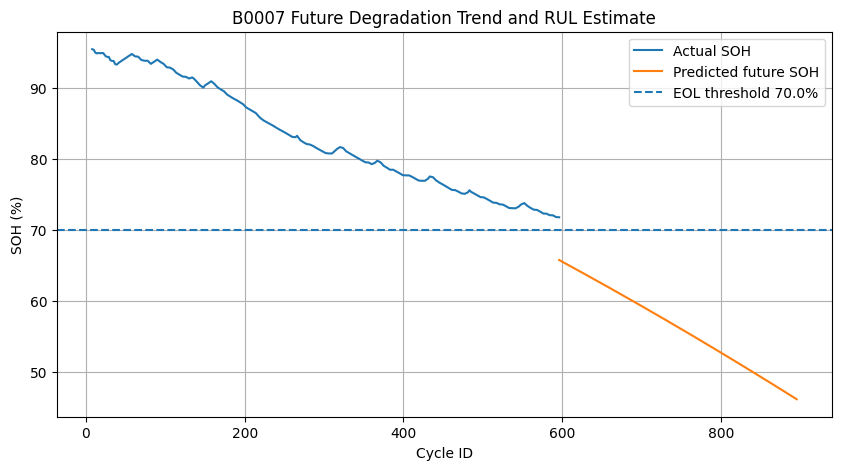

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(df_model["cycle_id"], df_model["soh_percent_smoothed"], label="Actual SOH")
plt.plot(future_df["cycle_id"], future_df["predicted_soh"], label="Predicted future SOH")
plt.axhline(EOL_THRESHOLD, linestyle="--", label=f"EOL threshold {EOL_THRESHOLD}%")

plt.xlabel("Cycle ID")
plt.ylabel("SOH (%)")
plt.title("B0007 Future Degradation Trend and RUL Estimate")
plt.legend()
plt.grid(True)
plt.show()